<a href="https://colab.research.google.com/github/erica-suqui/CSC-398-Final/blob/main/Submitted_xG_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tem members:
Erica

Ali

Eric






In [104]:
!pip install mplsoccer

#Predicting Expected Goals (xG) Using Shot Characteristics in Soccer

In [105]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from mplsoccer import Pitch

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder


from sklearn.metrics import accuracy_score

Import DataFrame

In [106]:
shots = pd.read_csv('mancity_xg_ml_ready.csv')
shots.head(10)


,X,Y,x_m,y_m,dist_to_goal,shot_angle_rad,shot_angle_deg,minute,is_goal,sit_DirectFreekick,...,act_OffsidePass,act_Pass,act_Rebound,act_Standard,act_Tackle,act_TakeOn,act_Throughball,act_Unknown,ha_a,ha_h
0,0.916,0.569,96.179998,38.692001,9.990360,0.641674,36.765208,1,0,False,...,False,False,False,False,False,False,False,False,False,True
1,0.888,0.481,93.240003,32.707999,11.830756,0.597256,34.220273,2,0,False,...,False,False,False,False,False,False,False,True,False,True
2,0.909,0.503,95.445002,34.203999,9.557176,0.731346,41.903025,2,0,False,...,False,False,False,False,False,False,False,False,False,True
3,0.848,0.507,89.040003,34.476001,15.967093,0.450483,25.810794,53,0,False,...,False,False,False,False,False,False,False,True,False,True
4,0.681,0.395,71.504998,26.860000,34.247551,0.208387,11.939672,55,0,False,...,False,True,False,False,False,False,False,False,False,True
5,0.889,0.723,93.345002,49.164002,19.125531,0.237532,13.609583,62,0,False,...,False,False,False,False,False,False,False,False,False,True
6,0.766,0.337,80.429998,22.916001,26.954406,0.247045,14.154621,8,0,False,...,False,False,False,False,False,False,False,False,True,False
7,0.841,0.392,88.304998,26.656001,18.238898,0.365575,20.945906,13,0,False,...,False,True,False,False,False,False,False,False,True,False
8,0.936,0.503,98.279998,34.203999,6.723097,0.996845,57.115002,20,0,False,...,False,False,False,False,False,False,False,False,True,False
9,0.885,0.500,92.925000,34.000000,12.075000,0.588607,33.724699,35,1,False,...,False,False,False,True,False,False,False,False,True,False


In [107]:
df = pd.read_csv('mancity_xg_full_reference.csv')

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Preprocessing Data - Eric

# Dropping is goal as we are focusing expected goals - Erica

In [109]:
x = df['xG']
shots.insert(len(shots.columns),'xG',x)
shots.drop(columns=['is_goal'],inplace=True)
shots.head(10)

,X,Y,x_m,y_m,dist_to_goal,shot_angle_rad,shot_angle_deg,minute,sit_DirectFreekick,sit_FromCorner,...,act_Pass,act_Rebound,act_Standard,act_Tackle,act_TakeOn,act_Throughball,act_Unknown,ha_a,ha_h,xG
0,0.916,0.569,96.179998,38.692001,9.990360,0.641674,36.765208,1,False,True,...,False,False,False,False,False,False,False,False,True,0.071387
1,0.888,0.481,93.240003,32.707999,11.830756,0.597256,34.220273,2,False,True,...,False,False,False,False,False,False,True,False,True,0.039106
2,0.909,0.503,95.445002,34.203999,9.557176,0.731346,41.903025,2,False,True,...,False,False,False,False,False,False,False,False,True,0.039392
3,0.848,0.507,89.040003,34.476001,15.967093,0.450483,25.810794,53,False,False,...,False,False,False,False,False,False,True,False,True,0.060420
4,0.681,0.395,71.504998,26.860000,34.247551,0.208387,11.939672,55,False,False,...,True,False,False,False,False,False,False,False,True,0.012051
5,0.889,0.723,93.345002,49.164002,19.125531,0.237532,13.609583,62,False,False,...,False,False,False,False,False,False,False,False,True,0.023833
6,0.766,0.337,80.429998,22.916001,26.954406,0.247045,14.154621,8,False,False,...,False,False,False,False,False,False,False,True,False,0.012449
7,0.841,0.392,88.304998,26.656001,18.238898,0.365575,20.945906,13,False,False,...,True,False,False,False,False,False,False,True,False,0.070360
8,0.936,0.503,98.279998,34.203999,6.723097,0.996845,57.115002,20,False,False,...,False,False,False,False,False,False,False,True,False,0.484085
9,0.885,0.500,92.925000,34.000000,12.075000,0.588607,33.724699,35,False,False,...,False,False,True,False,False,False,False,True,False,0.761169


In [110]:
shots.shape

(893, 39)

Erica - Shot Map

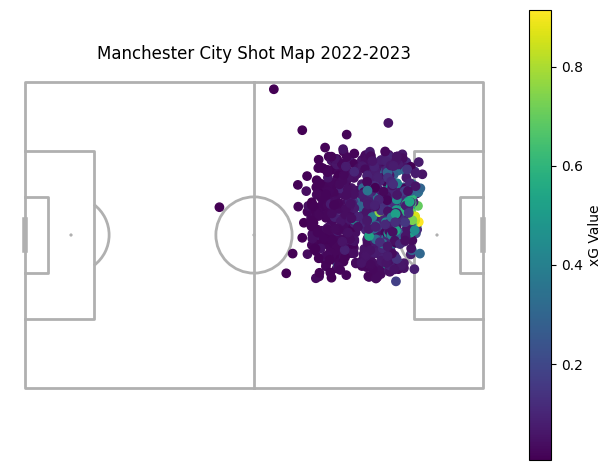

In [111]:
x_plot = shots['X'] * 105
y_plot = shots['Y'] * 68

pitch = Pitch()
fig, ax = pitch.draw()
sc = pitch.scatter(
    x_plot,
    y_plot,
    c=shots['xG'],
    ax=ax
)

plt.colorbar(sc, ax=ax, label='xG Value')
plt.title('Manchester City Shot Map 2022-2023')
plt.show()

**bold text**##label encoding: turning all boolean values to 0's and 1's

Allison - All visuals except shot map

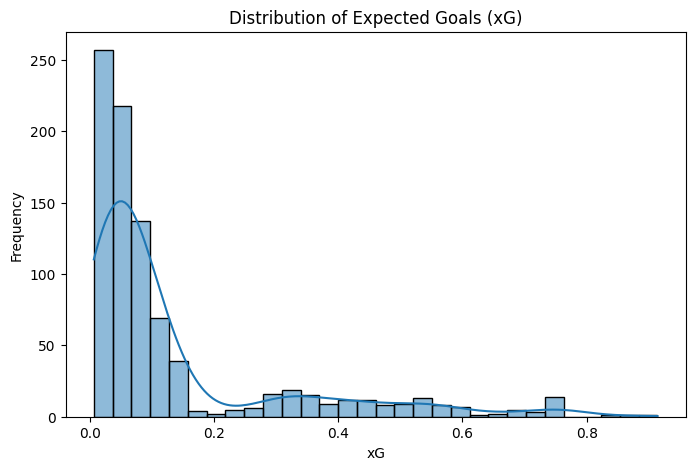

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(shots['xG'], bins=30, kde=True)
plt.title("Distribution of Expected Goals (xG)")
plt.xlabel("xG")
plt.ylabel("Frequency")
plt.show()

In [113]:
shots.drop(columns=['ha_a','x_m','y_m','shot_angle_rad'],inplace=True)
shots.replace({True: 1, False: 0})


/tmp/ipykernel_12716/2287610763.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shots.replace({True: 1, False: 0})


,X,Y,dist_to_goal,shot_angle_deg,minute,sit_DirectFreekick,sit_FromCorner,sit_OpenPlay,sit_Penalty,sit_SetPiece,...,act_OffsidePass,act_Pass,act_Rebound,act_Standard,act_Tackle,act_TakeOn,act_Throughball,act_Unknown,ha_h,xG
0,0.916,0.569,9.990360,36.765208,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0.071387
1,0.888,0.481,11.830756,34.220273,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0.039106
2,0.909,0.503,9.557176,41.903025,2,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0.039392
3,0.848,0.507,15.967093,25.810794,53,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0.060420
4,0.681,0.395,34.247551,11.939672,55,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0.012051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,0.899,0.548,11.095931,35.278989,89,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0.110258
889,0.924,0.539,8.409131,45.542440,89,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0.123962
890,0.958,0.503,4.414713,79.309433,89,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0.144023
891,0.905,0.632,13.418987,23.657445,90,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0.063404


##Exploratory Data Analysis - Erica

##All Current Features in the dataframe

In [114]:
print(shots.columns)

Index(['X', 'Y', 'dist_to_goal', 'shot_angle_deg', 'minute',
       'sit_DirectFreekick', 'sit_FromCorner', 'sit_OpenPlay', 'sit_Penalty',
       'sit_SetPiece', 'type_Head', 'type_LeftFoot', 'type_OtherBodyPart',
       'type_RightFoot', 'act_Aerial', 'act_BallRecovery', 'act_BallTouch',
       'act_BlockedPass', 'act_Chipped', 'act_CornerAwarded', 'act_Cross',
       'act_Dispossessed', 'act_Foul', 'act_HeadPass', 'act_LayOff',
       'act_OffsidePass', 'act_Pass', 'act_Rebound', 'act_Standard',
       'act_Tackle', 'act_TakeOn', 'act_Throughball', 'act_Unknown', 'ha_h',
       'xG'],
      dtype='object')


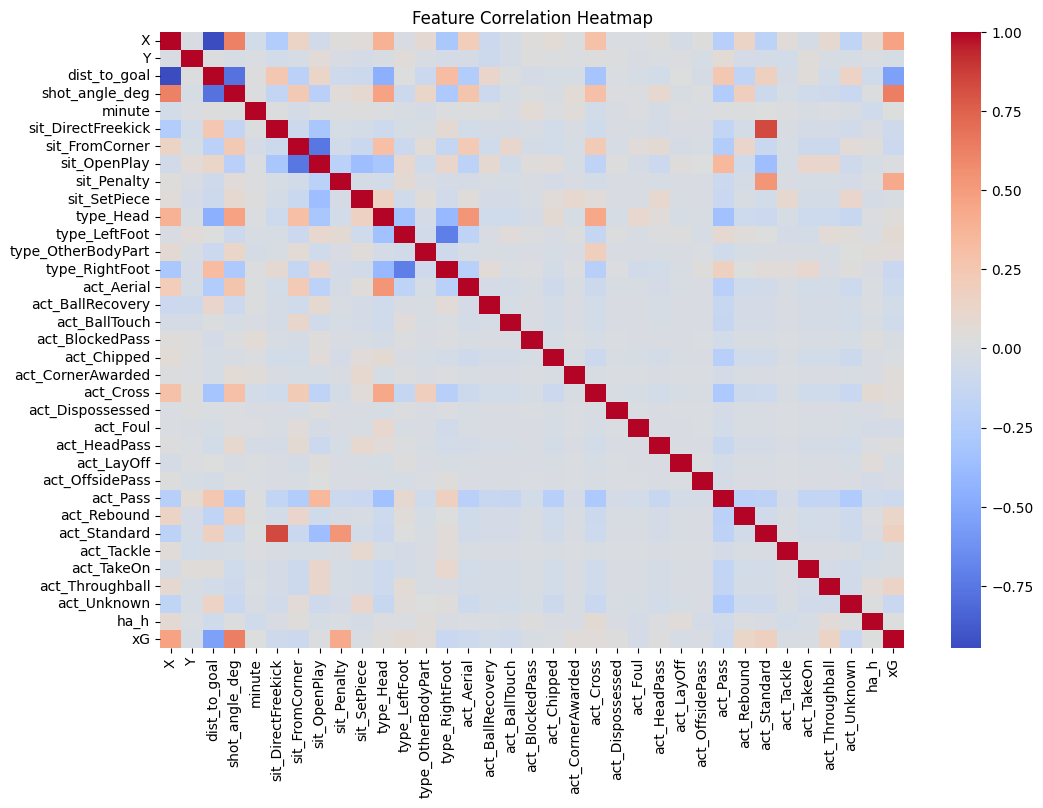

In [115]:
plt.figure(figsize=(12,8))
sns.heatmap(shots.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

##Standardizing Features

In [116]:
X = shots.loc[:,'X':'ha_h']
y = shots['xG']


X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=3,test_size = 0.2)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


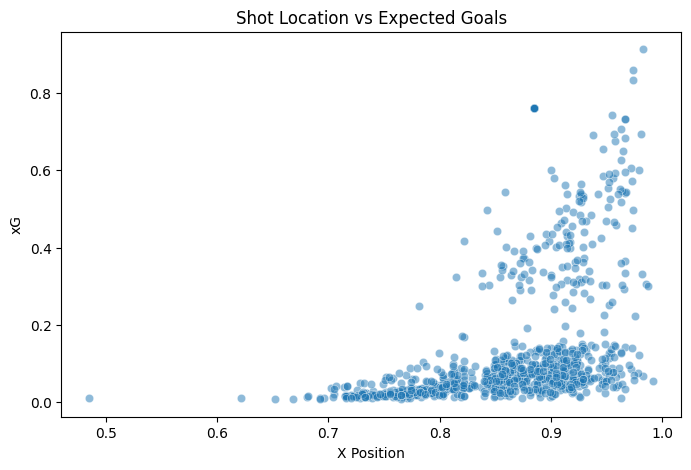

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=shots['X'], y=shots['xG'], alpha=0.5)
plt.title("Shot Location vs Expected Goals")
plt.xlabel("X Position")
plt.ylabel("xG")
plt.show()

## Function to evaluate all models - Erica



In [118]:
def evaluate_model(name,y_actual,y_predict):
  r2 = r2_score(y_actual,y_predict)
  mae = mean_absolute_error(y_actual,y_predict)
  rmse = np.sqrt(mean_squared_error(y_actual, y_predict))

  print(f"{name}\n")
  print('-'*20)
  print(f"R2: {r2:.2f}")
  print(f"MAE: {mae:.2f}")
  print(f"RMSE: {rmse:.2f}")

## 1) Linear Regression Erica

In [119]:
ols = LinearRegression()
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_test)

evaluate_model("OLS", y_test, ols_pred)

OLS

--------------------
R2: 0.67
MAE: 0.07
RMSE: 0.10


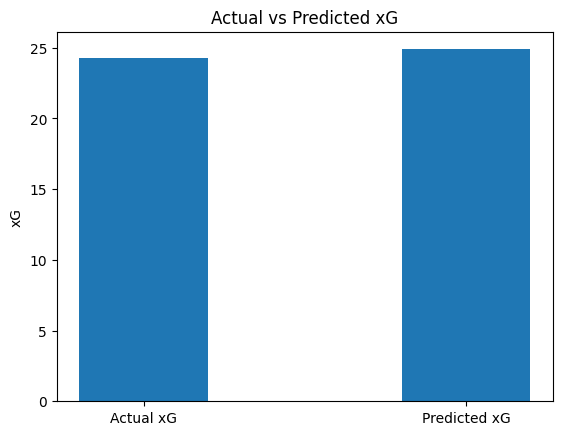

In [120]:
actual_total = y_test.sum()
predicted_total = ols_pred.sum()

plt.bar(['Actual xG', 'Predicted xG'],
        [actual_total, predicted_total], width=0.4)
plt.title('Actual vs Predicted xG')
plt.ylabel('xG')
plt.show()

##2) Random Forest Regression - Erica

In [121]:
random_forest_regressor = RandomForestRegressor(n_estimators=200,random_state=0)
random_forest_regressor.fit(X_train,y_train)

rf_predicted = random_forest_regressor.predict(X_test)

evaluate_model("Random Forest Regressor",rf_predicted,y_test)


Random Forest Regressor

--------------------
R2: 0.55
MAE: 0.06
RMSE: 0.10


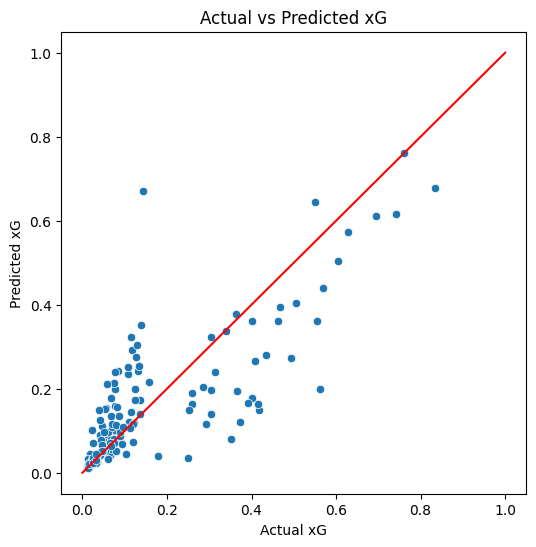

In [122]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=rf_predicted)
plt.xlabel("Actual xG")
plt.ylabel("Predicted xG")
plt.title("Actual vs Predicted xG")
plt.plot([0,1],[0,1], color='red')
plt.show()

## 3) Graident Boost Regression - Erica

In [123]:
xgb_model = GradientBoostingRegressor(n_estimators=200,random_state=0)
xgb_model.fit(X_train,y_train)

xgb_predicted = xgb_model.predict(X_test)

evaluate_model("Gradient Boosting Regressor",xgb_predicted,y_test)

Gradient Boosting Regressor

--------------------
R2: 0.52
MAE: 0.06
RMSE: 0.11


##Feature Importance - Erica

In [124]:
importance_features = pd.DataFrame({
    "Features ": X.columns,
    "Importance": random_forest_regressor.feature_importances_
    })

importance_features = importance_features.sort_values("Importance", ascending=False)
importance_features.head(10).round(2)

,Features,Importance
3,shot_angle_deg,0.38
2,dist_to_goal,0.15
8,sit_Penalty,0.09
0,X,0.05
28,act_Standard,0.05
14,act_Aerial,0.04
4,minute,0.04
1,Y,0.03
10,type_Head,0.03
31,act_Throughball,0.03


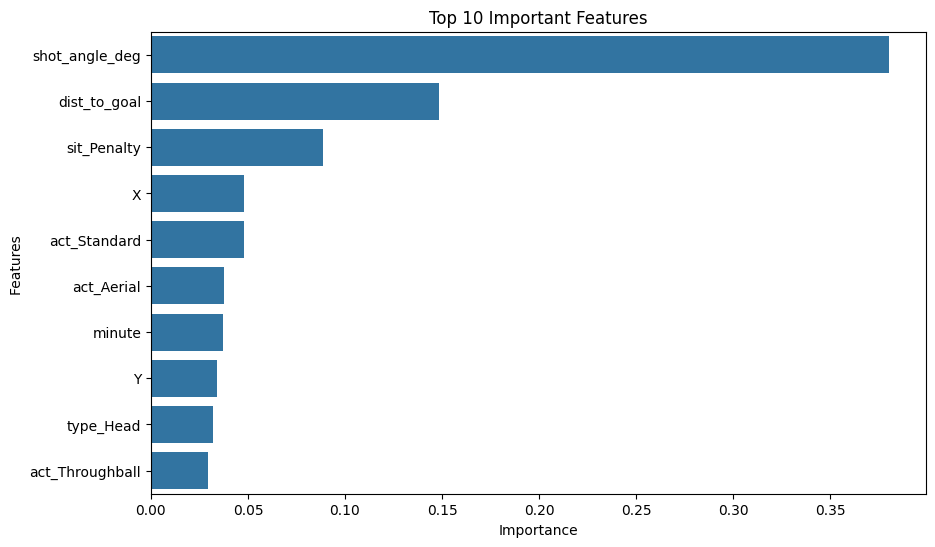

In [125]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_features.head(10),
    x="Importance",
    y="Features "
)
plt.title("Top 10 Important Features")
plt.show()

##Type of Shot - situation type Feature Importance, Top 10 - Erica

In [126]:
importance_features[importance_features['Features '].str.startswith('sit_')]

,Features,Importance
8,sit_Penalty,0.088534
7,sit_OpenPlay,0.025342
6,sit_FromCorner,0.017099
9,sit_SetPiece,0.001217
5,sit_DirectFreekick,0.000871


In [127]:
importance_features[importance_features['Features '].str.startswith('type_')]

,Features,Importance
10,type_Head,0.031747
11,type_LeftFoot,0.006334
13,type_RightFoot,0.003124
12,type_OtherBodyPart,0.000530


In [128]:
importance_features[importance_features['Features '].str.startswith('act')].round(3).head(5)

,Features,Importance
28,act_Standard,0.048
14,act_Aerial,0.038
31,act_Throughball,0.030
26,act_Pass,0.028
20,act_Cross,0.010
